<a href="https://colab.research.google.com/github/elzbietapiechota/learning-pipeline/blob/main/Pipeline_GridSearchCV_pingwiny.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
# manipulacja danymi
import numpy as np
import pandas as pd

# wizualizacja
import matplotlib.pyplot as plt
import seaborn as sns

# podział danych na zbiory treningowe/walidacyjne/testowe
from sklearn.model_selection import train_test_split, GridSearchCV

# budowa Pipeline
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer

# Preprocessing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures, PowerTransformer

# redukcja wymiarowości
from sklearn.decomposition import PCA

# model
from sklearn.linear_model import LogisticRegression

# ewaluacja
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, f1_score, roc_auc_score

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, f1_score
from sklearn.preprocessing import label_binarize

metrics_list = []
models = []
models_names = []
predictions_proba_list = []

def calculate_metrics(model, name, X_checked, y_checked):
    models.append(model)
    models_names.append(name)
    predictions = model.predict(X_checked)
    predictions_proba = model.predict_proba(X_checked)
    predictions_proba_list.append(predictions_proba)
    species_names = ['Gatunek 0', 'Gatunek 1', 'Gatunek 2']

    ############## metryki dla sprawdzanego modelu ################
    # Precision, Recall, F1, Accuracy
    print(f"Model: {name}")
    print(classification_report(y_checked, predictions, target_names=species_names))

    # Confusion matrix
    plt.figure(figsize=(6, 5))
    cm = confusion_matrix(y_checked, predictions)
    ax = sns.heatmap(cm, annot=True, cmap='Blues', fmt='.0f',
                     xticklabels=species_names, yticklabels=species_names) # <--- ZMIANA: Dodane etykiety gatunków
    ax.set_title(f'Confusion Matrix\n\n')
    ax.set_xlabel('\nPredicted Values')
    ax.set_ylabel('Actual Values')
    plt.show()

    # plot ROC curve
    y_checked_bin = label_binarize(y_checked, classes=[0, 1, 2])

    fig = plt.figure(figsize=(7, 7))
    plt.plot([0, 1], [0, 1], 'k--')
    for model_selected, name_selected, pred_proba in zip(models, models_names, predictions_proba_list):
        fpr_grid = np.linspace(0, 1, 100)
        tpr_list = []
        for i in range(3):
            fpr_c, tpr_c, _ = roc_curve(y_checked_bin[:, i], pred_proba[:, i])
            tpr_list.append(np.interp(fpr_grid, fpr_c, tpr_c))

        mean_tpr = np.mean(tpr_list, axis=0)
        mean_auc = roc_auc_score(y_checked, pred_proba, multi_class='ovr', average='macro')

        plt.plot(fpr_grid, mean_tpr, label=f'{name_selected}')

    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.show()

    f1_metric = f1_score(y_checked, predictions, average='macro')
    auc_metric = roc_auc_score(y_checked, predictions_proba, multi_class='ovr', average='macro')

    metrics_list.append({'Model': name, 'F1_score': f1_metric, 'AUC': auc_metric})

    return pd.DataFrame(metrics_list)

In [17]:
import pandas as pd
penguins = pd.read_csv('penguins.csv')
penguins

,CulmenLength,CulmenDepth,FlipperLength,BodyMass,Species
0,39.1,18.7,181.0,3750.0,0
1,39.5,17.4,186.0,3800.0,0
2,40.3,18.0,195.0,3250.0,0
3,NaN,NaN,NaN,NaN,0
4,36.7,19.3,193.0,3450.0,0
...,...,...,...,...,...
339,55.8,19.8,207.0,4000.0,2
340,43.5,18.1,202.0,3400.0,2
341,49.6,18.2,193.0,3775.0,2
342,50.8,19.0,210.0,4100.0,2


In [18]:
X = penguins.drop(columns=['Species']).copy()
y = penguins['Species'].copy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

In [19]:
num_features = ['CulmenLength','CulmenDepth','FlipperLength','BodyMass']

model_pipeline_v1 = Pipeline(steps=[
    ('fill_missings', SimpleImputer(strategy='mean')),
    ('polynomial_features', PolynomialFeatures(degree=3)),
    ('scaler_1', StandardScaler()),
    ('pca', PCA(n_components=0.95)),
    ('scaler_2', StandardScaler()),
    ('model', LogisticRegression(max_iter=10000))
])

model_pipeline_v1.fit(X_train, y_train)

Pipeline(steps=[('fill_missings', SimpleImputer()),
                ('polynomial_features', PolynomialFeatures(degree=3)),
                ('scaler_1', StandardScaler()), ('pca', PCA(n_components=0.95)),
                ('scaler_2', StandardScaler()),
                ('model', LogisticRegression(max_iter=10000))])

Model: Logistic Regression (pipeline)
              precision    recall  f1-score   support

   Gatunek 0       0.97      1.00      0.99        38
   Gatunek 1       1.00      1.00      1.00        31
   Gatunek 2       1.00      0.94      0.97        17

    accuracy                           0.99        86
   macro avg       0.99      0.98      0.99        86
weighted avg       0.99      0.99      0.99        86



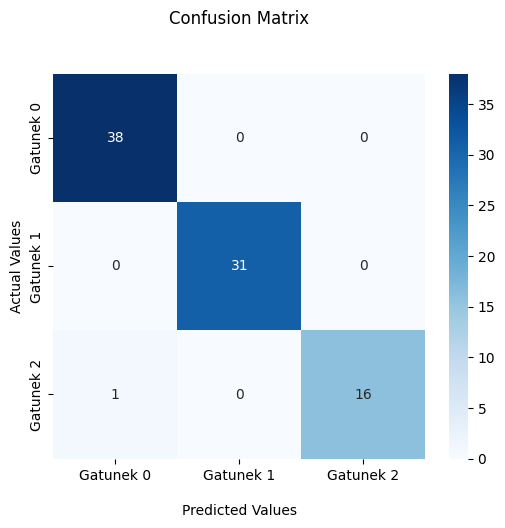

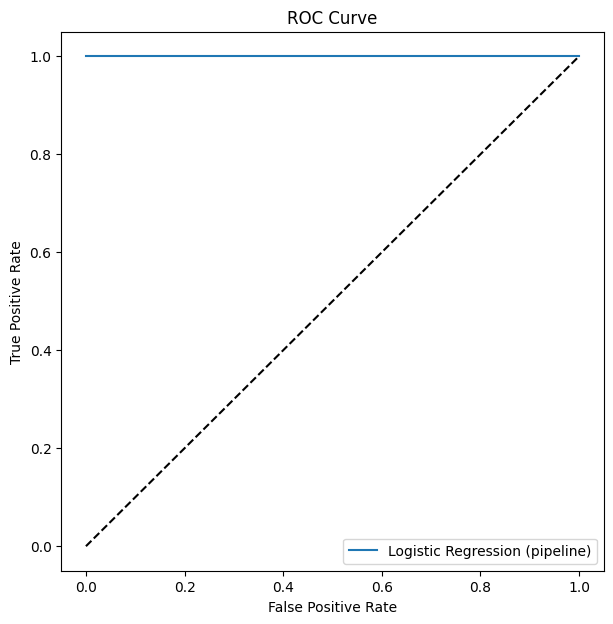

,Model,F1_score,AUC
0,Logistic Regression (pipeline),0.98557,1.0


In [20]:
calculate_metrics(model_pipeline_v1, 'Logistic Regression (pipeline)', X_test, y_test)

In [21]:
params = {
    'fill_missings__strategy': ['mean', 'median'],
    'polynomial_features__degree': [1, 2, 3],
    'pca__n_components': [0.85, 0.90, 0.95, 0.99, 0.99999],
    'model__C': np.logspace(-3, 3, 15)
}

grid_search = GridSearchCV(model_pipeline_v1, params, cv=10, n_jobs=-1, verbose=10, scoring='f1_macro')
grid_search.fit(X_train, y_train)
print('Wybrane hiperparametry: ', grid_search.best_params_)
model_pipeline_v2 = grid_search.best_estimator_

Fitting 10 folds for each of 450 candidates, totalling 4500 fits
Wybrane hiperparametry:  {'fill_missings__strategy': 'mean', 'model__C': np.float64(19.306977288832496), 'pca__n_components': 0.9, 'polynomial_features__degree': 1}


Model: Logistic Regression v2 (pipeline)
              precision    recall  f1-score   support

   Gatunek 0       0.97      1.00      0.99        38
   Gatunek 1       1.00      1.00      1.00        31
   Gatunek 2       1.00      0.94      0.97        17

    accuracy                           0.99        86
   macro avg       0.99      0.98      0.99        86
weighted avg       0.99      0.99      0.99        86



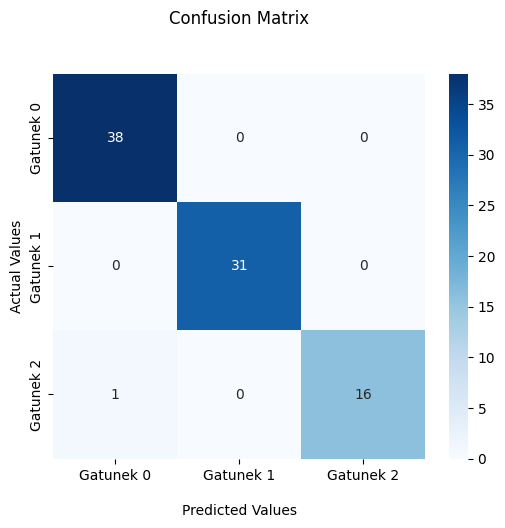

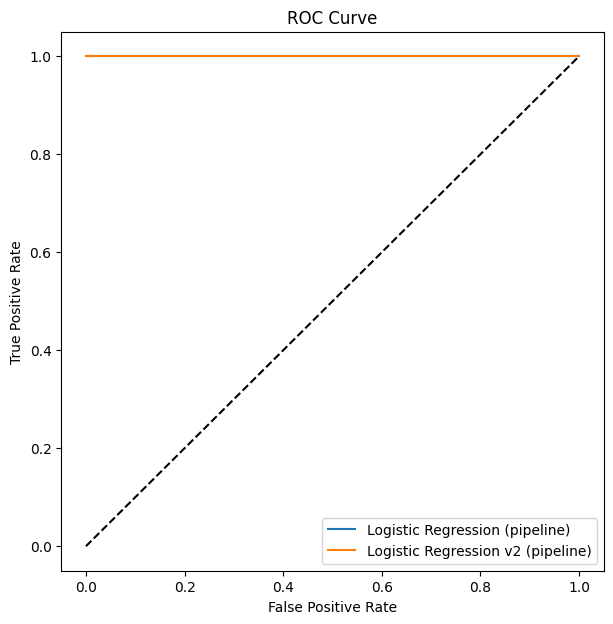

,Model,F1_score,AUC
0,Logistic Regression (pipeline),0.98557,1.0
1,Logistic Regression v2 (pipeline),0.98557,1.0


In [22]:
calculate_metrics(model_pipeline_v2, 'Logistic Regression v2 (pipeline)', X_test, y_test)